# 4. What is missing or malformed

**Week 1, Wednesday. Chapter 4 of 6.** Chapter 3 kept 186 orders by the identity rule and set 15 rows aside; Q1 is Rs 1,90,00,000. This chapter decides each missing and malformed value, and writes the reason down.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

**The need.** The 186 kept orders still carry two kinds of defect. One order has no status, and
Operations reads the delivered share of orders every week. Fifty-five orders have no discount,
which Tuesday met. And the pass needs a policy for any amount that does not convert, because the
next export will carry one without a twin. Each choice either keeps revenue whole, invents a fact
or deletes one, and Anand's analyst will read every choice in the log.

**Who else faces it.** On the evening of Friday 12 December 2014 a repricing tool used by Amazon UK sellers set hundreds of items to 1p for about an hour; Amazon said most orders were cancelled once the error was spotted (BBC News, 15 December 2014, checked 30 Sep 2026). A value that fell to a default sold real stock, which is what a coerced zero does to a report.

Kalpa Retail's business, its metrics and who decides what are in the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`; this notebook assumes it.

**Setup.** The tools so far and the identity rule from chapter 3, so this notebook starts from the 186 kept orders.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

def identity_rule(rows, key="order_id"):
    """One row per order: the first copy whose amount converts stays, and every other row is logged."""
    groups = {}
    for r in rows:
        groups.setdefault(r[key], []).append(r)
    kept, log = [], []
    for k, rs in groups.items():
        valid = [r for r in rs if convert(r["amount"])[0] is not None]
        keep = (valid or rs)[0]
        kept.append(keep)
        for r in rs:
            if r is keep:
                continue
            differs = [f for f in r if f != "line" and r[f] != keep[f]]
            reason = ("copy whose amount does not convert; its twin carries the value"
                      if convert(r["amount"])[0] is None else "second copy of the order")
            if differs and "amount" not in differs:
                reason += "; differs on " + ", ".join(differs)
            log.append({"line": r["line"], "order_id": k, "quarter": r["quarter"], "segment": r["segment"],
                        "amount": r["amount"], "rule": key, "reason": reason, "kept_line": keep["line"]})
    return kept, log

raw = read_orders()
kept, set_aside = identity_rule(raw)
clean = [dict(r, amount=convert(r["amount"])[0]) for r in kept]
print(len(clean), "orders kept;", len(set_aside), "rows set aside")

186 orders kept; 15 rows set aside


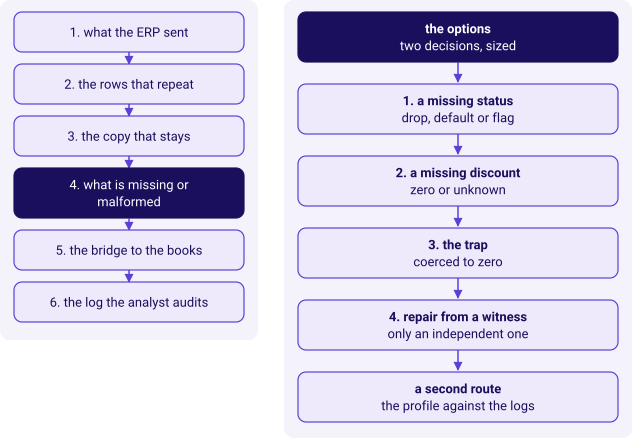

In [2]:
kit.side_by_side(
    kit.ladder(["what the ERP sent", "the rows that repeat", "the copy that stays", "what is missing or malformed", "the bridge to the books", "the log the analyst audits"], lit=3, show=False),
    kit.vflow(["the options\ntwo decisions, sized", "1. a missing status\ndrop, default or flag", "2. a missing discount\nzero or unknown", "3. the trap\ncoerced to zero", "4. repair from a witness\nonly an independent one", "a second route\nthe profile against the logs"], lit=0, show=False),
)

## The options

Two decisions, each with its options.

| A missing status | What it claims |
|---|---|
| a) Drop the order | the order never happened |
| b) Default it to delivered | the order reached the customer |
| c) Impute it from the customer's last order | the customer's history decides this order's fate |
| d) Keep it and flag it unknown | the order happened and its fate is unknown |

| An amount that does not convert | What it does |
|---|---|
| a) Coerce it to zero | the loop runs and the order is worth nothing |
| b) Reject it to the log | the row leaves revenue, with a line and a reason |
| c) Repair it by reading the text | a person or a parser turns the text into a number |
| d) Repair it from an independent copy | a second source that carries the value supplies it |

missing status,Q2 revenue,Q2 orders,delivered,delivered share
a) drop,"Rs 1,86,98,150",85,57,67.1%
b) default delivered,"Rs 1,87,00,000",86,58,67.4%
c) impute from last order,"Rs 1,87,00,000",86,58,67.4%
d) keep and flag,"Rs 1,87,00,000",86,57,66.3%


unreadable amount,Q1 against the books,what it leaves
a) coerce to zero,"-Rs 1,790",an order at Rs 0 in the clean file
b) reject to the log,"Rs 0 here, the whole order elsewhere",revenue short until repaired
c) repair by reading,see the invented case below,a guess dressed as a value
d) repair from a copy,Rs 0,needs a copy that is independent


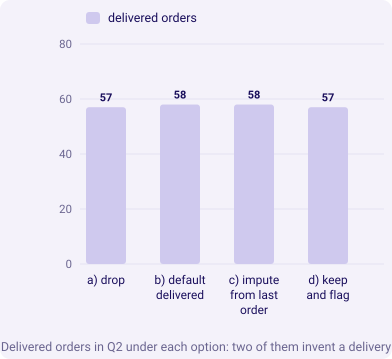

In [3]:
q2 = [r for r in clean if r["quarter"] == "Q2"]
no_status = [r for r in q2 if not r["status"]]
delivered = sum(1 for r in q2 if r["status"] == "delivered")
status_opts = [("a) drop", Q(q2, "Q2") - sum(r["amount"] for r in no_status), len(q2) - 1, delivered),
               ("b) default delivered", Q(q2, "Q2"), len(q2), delivered + 1),
               ("c) impute from last order", Q(q2, "Q2"), len(q2), delivered + 1),
               ("d) keep and flag", Q(q2, "Q2"), len(q2), delivered)]
kit.table(["missing status", "Q2 revenue", "Q2 orders", "delivered", "delivered share"],
          [(n, kit.rupees(v), o, d, f"{d / o:.1%}") for n, v, o, d in status_opts],
          caption="The missing status, each option sized on Q2")
coerced_kept = []
seen = {}
for r in raw:                       # coerce first, then keep the first copy, as a hurried pass would
    r2 = dict(r, amount=convert(r["amount"])[0] or 0)
    seen.setdefault(r2["order_id"], r2)
coerced_kept = list(seen.values())
amount_opts = [("a) coerce to zero", kit.rupees(Q(coerced_kept, "Q1") - BOOKS_Q1), "an order at Rs 0 in the clean file"),
               ("b) reject to the log", "Rs 0 here, the whole order elsewhere", "revenue short until repaired"),
               ("c) repair by reading", "see the invented case below", "a guess dressed as a value"),
               ("d) repair from a copy", kit.rupees(Q(clean, "Q1") - BOOKS_Q1), "needs a copy that is independent")]
kit.table(["unreadable amount", "Q1 against the books", "what it leaves"], amount_opts,
          caption="The unreadable amount, each option sized on this export")
kit.columns([n for n, *_ in status_opts], [("delivered orders", [d for *_, d in status_opts])],
            title="Delivered orders in Q2 under each option: two of them invent a delivery")

**The best-fit calls.** For the status, d: revenue is booked value whatever the status, so the order
stays in revenue, and the flag keeps it out of the delivered count, which stays at 57 of 86. For the
amount, b by default and d when an independent copy exists, which on this file it does: the
identity rule already kept the twin that carries the value. **The facts that would change them:**
for the status, a delivery system that can be asked, which turns the flag into a lookup; for the
amount, a second export from the same extract, which is a copy of the defect and no witness at all.

## 1. A missing status

**Predict before you run.** Which decision keeps Q2 revenue and the delivered share both honest?
a) drop; b) default delivered; c) impute; d) keep and flag.

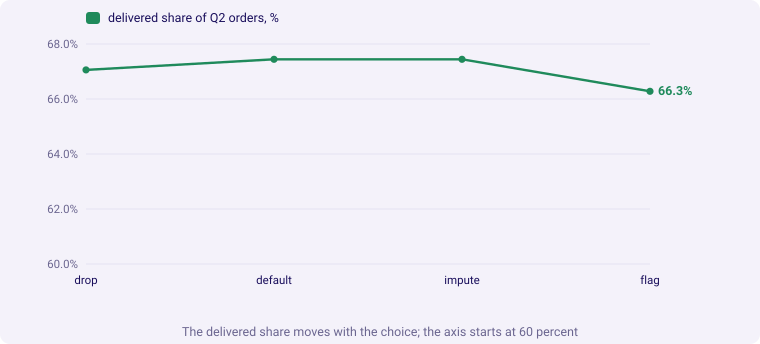

In [4]:
flags = [{"field": "status", "decision": "keep and flag", "why": "booked revenue; its fate is unknown"} for _ in no_status]
kit.line(["drop", "default", "impute", "flag"], [("delivered share of Q2 orders, %", [100 * d / o for _, _, o, d in status_opts], "good")],
         fmt=lambda v: f"{v:.1f}%", lo=60, title="The delivered share moves with the choice; the axis starts at 60 percent")
kit.check("exactly one kept order has no status", len(no_status) == 1)
kit.check("keep and flag leaves Q2 whole", status_opts[3][1] == 18700000, kit.rupees(status_opts[3][1]))
kit.check("only a default or an imputation adds a delivery", status_opts[1][3] == status_opts[2][3] == delivered + 1)

**What happened.** The answer is d. Dropping removes a booked order that Finance has; defaulting and
imputing each add a delivery nobody recorded, lifting the delivered share from 66.3 to 67.4 percent.
Keep and flag leaves Q2 at Rs 1,87,00,000 and writes one line in the flags log.

## 2. A missing discount: zero, or unknown?

Tuesday's trap read a missing discount as zero. Revenue here is the booked amount, so the discount
does not move it; it moves any average discount a report quotes.

**Predict before you run.** The average discount over orders that carry one, against the average
with the missing ones read as zero: how far apart? a) the same; b) a few rupees; c) about 30
percent lower with zeros; d) higher with zeros.

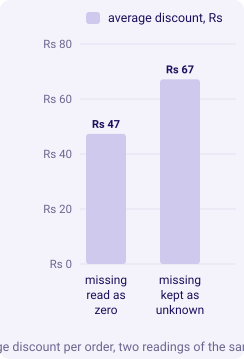

In [5]:
with_disc = [int(r["discount"]) for r in clean if r["discount"] != ""]
as_zero = with_disc + [0] * (len(clean) - len(with_disc))
avg_known, avg_zero = sum(with_disc) / len(with_disc), sum(as_zero) / len(as_zero)
kit.columns(["missing read as zero", "missing kept as unknown"], [("average discount, Rs", [avg_zero, avg_known])],
            fmt=lambda v: f"Rs {v:.0f}", title="Average discount per order, two readings of the same file")
kit.check("55 kept orders carry no discount", len(clean) - len(with_disc) == 55)
kit.check("zeros pull the average down by over a quarter", avg_zero < 0.75 * avg_known, f"Rs {avg_zero:.0f} against Rs {avg_known:.0f}")

**What happened.** The answer is c. Reading 55 absences as zero pulls the average from about Rs 67 to
about Rs 47. The decision is keep and flag: revenue does not need the field, and any discount
figure is quoted over the orders that carry one, with the count beside it.

## 3. The trap: coerce every failure to zero, and the file looks clean

**The plausible wrong answer.** The `ValueError` from chapter 1 stops the loop, so the hurried
analyst writes a helper that turns anything unreadable into zero, then runs the same first-copy
dedupe everybody reaches for.

In [6]:
def to_int(value):
    try:
        return int(value)
    except ValueError:
        return 0                     # "so the loop does not crash"

coerced = [dict(r, amount=to_int(r["amount"])) for r in raw]
failures = sum(1 for r in coerced if not isinstance(r["amount"], int))
kit.stats([(f"{len(raw) - failures} of {len(raw)}", "amounts convert", "the coerced profile"),
           ("0", "rows in the rejects log", "nothing to explain"),
           (kit.rupees(Q(coerced_kept, "Q1")), "Q1 after the dedupe", "rounds to 1.9 crore")],
          caption="The coerced pass, as it would be reported")

**Why it is wrong.** A zero is a claim that Kalpa sold that order for nothing. Once the unreadable
copy is worth Rs 0 it passes as valid, the identity rule can no longer tell it from its twin, the
first copy wins, and Q1 lands Rs 1,790 short with an order at Rs 0 in a file the note calls clean.
The profile's failure count went from one to zero while nothing was fixed. The check asks whether
a Kalpa order can be worth nothing.

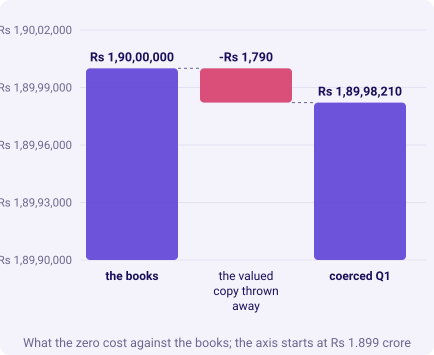

In [7]:
smallest_real = min(r["amount"] for r in clean)
zero_orders = [r for r in coerced_kept if r["amount"] == 0]
kit.check("the coerced pass keeps an order at Rs 0", len(zero_orders) == 1, f"{len(zero_orders)} order")
kit.check("no real order in the export is below Rs 600", smallest_real >= 600, f"the smallest is {kit.rupees(smallest_real)}")
kit.check("the coerced pass misses the books by Rs 1,790", BOOKS_Q1 - Q(coerced_kept, "Q1") == 1790)
kit.bridge(("the books", BOOKS_Q1), [("the valued copy thrown away", -1790)], end_label="coerced Q1",
           lo=18990000, title="What the zero cost against the books; the axis starts at Rs 1.899 crore")

**The fix, and what changed.** Reject to the log, then let the identity rule prefer the copy that
validates: the Rs 0 order leaves the clean file, the twin with the value stays, and Q1 is back on
the books. The profile reports one failure, which is the truth about the export.

## 4. The harder variant: repair only from an independent witness

Two repairs look tempting. Reading the text as a number, on an invented pair in which the first
copy says `fourteen` and the second `1400`:

In [8]:
WORDS = {"fourteen": 14, "twenty": 20}
invented_pair = [{"order_id": "INV-21", "amount": "fourteen"}, {"order_id": "INV-21", "amount": "1400"}]   # invented
read_as_word = WORDS[invented_pair[0]["amount"]]
kit.table(["repair", "value", "against the twin"], [("read the word", read_as_word, read_as_word - 1400),
                                                    ("take the twin", 1400, 0)], caption="Invented: a word is not an amount")
kit.check("reading the word misses the invented order by Rs 1,386", 1400 - read_as_word == 1386)

repair,value,against the twin
read the word,14,-1386
take the twin,1400,0


The other tempting repair is the JSON feed, which carries the same orders.

**Predict before you run.** For the orders the feed holds, how many amounts agree with the clean
file? a) all 119; b) 118, and the one that differs carries unreadable text; c) about half; d) none.

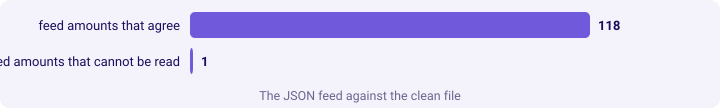

In [9]:
text = (DATA / "C2_W01_D03_orders_STUDENT.json").read_text(encoding="utf-8")
decoder, feed, at = json.JSONDecoder(), [], text.index("{")
while True:
    try:
        record, end = decoder.raw_decode(text, at)
    except json.JSONDecodeError:
        break
    feed.append(record)
    at = text.find("{", end)
    if at == -1:
        break
clean_by_id = {r["order_id"]: r["amount"] for r in clean}
agree = sum(1 for r in feed if convert(r.get("amount"))[0] == clean_by_id.get(r["order_id"]))
unreadable_in_feed = sum(1 for r in feed if convert(r.get("amount"))[0] is None)
kit.bars([("feed amounts that agree", agree), ("feed amounts that cannot be read", unreadable_in_feed)],
         title="The JSON feed against the clean file")
kit.check("the feed agrees on 118 of 119", agree == 118)
kit.check("the one it does not confirm is unreadable in the feed too", unreadable_in_feed == 1)

**What happened.** The answer is b. The feed repeats the defect, because it was cut from the same
extract, so it is a copy and no witness. The CSV's second extract carried the value, and the
identity rule already used it. The rule for the log: repair only from a source that could not have
copied the error, and name the source.

## A second route: the profile against the logs

The profile counts defects in aggregate and the logs list them row by row. The two must agree.

In [10]:
p = profile(clean)
kit.table(["defect", "from the profile of the clean file", "from the logs"],
          [("status missing", len(clean) - p["status"]["present"], len(flags)),
           ("amount that fails", p["amount"]["present"] - p["amount"]["convertible"], 0),
           ("discount missing", len(clean) - p["discount"]["present"], len(clean) - len(with_disc))])
kit.check("the profile and the flags log agree on the status", len(clean) - p["status"]["present"] == len(flags))
kit.check("no amount in the clean file fails", p["amount"]["convertible"] == len(clean))

defect,from the profile of the clean file,from the logs
status missing,1,1
amount that fails,0,0
discount missing,55,55


**When to switch.** The profile is how you find defects; the log is how you show them. Run the
profile on the clean file at the end of every pass, and a defect that got past the log shows as a
count that disagrees.

> **Kavya's review.** "Drop, default, or keep and flag: each is a claim about the business. Write
> the claim beside the decision. And never fill money."

### In the interview

**[S] How do you handle missing data?** "Measure it per field, then ask what the absence means,
because an absent discount and an absent status mean different things. Then one of three decisions
with a written reason: drop, fill a stated default, or keep and flag. I size each on the numbers it
moves: here dropping costs Rs 1,850 of booked revenue, a default adds a delivery nobody recorded,
and keep and flag moves nothing and says so. For money I never fill."

**Design. Coerce, reject or repair a malformed amount?** "Reject to a log by default, since a
coerced zero is a false value and hides the defect from every later check. Repair only from an
independent source, and name it. I would switch to repair-by-rule only for a known format issue,
such as a thousands separator, where the rule is exact and tested."

### Depth: missing at random, or not

Statisticians separate values missing completely at random from values whose absence depends on
something, such as discounts left blank only by one channel. Only the first can be dropped without
bending a rate. Imputation, filling a value from other records, belongs to model features with a
column that marks the filled values; for Finance, the answer stays keep and flag.

In [11]:
kit.check_summary()
print("Next: chapter 5 draws the bridge from 2.1 to 1.9 and recomputes Tuesday on the clean file.")

Next: chapter 5 draws the bridge from 2.1 to 1.9 and recomputes Tuesday on the clean file.
